# HDB Resale Price Regression — Notebook 16: PropertyGuru Listing Premium

Model 12 predicts resale *transaction* prices with R² = 0.937 and median error ~$27K. What happens when we apply it to PropertyGuru *listing* prices?

The gap between predicted transaction value and listing price = the **agent markup**. If agents list at 5% above predicted transaction value on average, that's the market's built-in negotiation cushion. If 168-priced listings have a *bigger* markup, agents are using the auspicious number to justify reaching further.

**Data:** 13,338 HDB listings scraped from PropertyGuru (as of March 2026).

In [1]:
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R
library(tidyverse)
library(sandwich)
library(lmtest)

# Transaction data (for training Model 12)
df <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)
df$remaining_lease_sq <- df$remaining_lease_years^2
df$month_factor <- factor(format(df$month, '%Y-%m'))

# PropertyGuru listings
pg <- read_csv('data/propertyguru_hdb_listings.csv', show_col_types = FALSE)
pg <- pg[!is.na(pg$price) & pg$price > 100000, ]

cat(sprintf('Transaction data: %s rows\n', format(nrow(df), big.mark = ',')))
cat(sprintf('PropertyGuru listings: %s rows\n', format(nrow(pg), big.mark = ',')))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Transaction data: 50,718 rows


PropertyGuru listings: 13,338 rows


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

In addition: Warning message:
One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat) 


## Map PropertyGuru variables to transaction format

PropertyGuru uses different column names and formats. We need to map them to match Model 12's variables. Some mappings are approximate — `floor_level` (High/Mid/Low) maps to rough storey midpoints, and `flat_model_grouped` is inferred from `hdb_type_code`.

In [3]:
%%R
# --- Map hdb_estate to town (direct match after toupper) ---
pg$town <- toupper(pg$hdb_estate)

# --- Map hdb_type_code to flat_type ---
pg$flat_type <- case_when(
    pg$hdb_type_code == '1R' ~ '1 ROOM',
    pg$hdb_type_code %in% c('2A', '2I', '2S', '2RF') ~ '2 ROOM',
    grepl('^3', pg$hdb_type_code) ~ '3 ROOM',
    grepl('^4', pg$hdb_type_code) ~ '4 ROOM',
    grepl('^5', pg$hdb_type_code) ~ '5 ROOM',
    pg$hdb_type_code %in% c('EA', 'EM', '6J') ~ 'EXECUTIVE',
    pg$hdb_type_code == 'MG' ~ 'MULTI-GENERATION',
    pg$hdb_type_code == 'TE' ~ '5 ROOM',   # terrace treated as 5-room
    TRUE ~ '4 ROOM'  # fallback for blanks
)

# --- Map hdb_type_code to flat_model_grouped ---
# NOTE: This mapping is approximate. Some codes (3NGm, 6J, MG, TE) have no
# direct counterpart in the transaction data and are mapped to the nearest
# equivalent or 'Other'. The model will still predict a reasonable price.
pg$flat_model_grouped <- case_when(
    pg$hdb_type_code %in% c('3A', '4A', '5A') ~ 'Model A',
    pg$hdb_type_code == '3Am' ~ 'Model A-Maisonette',
    pg$hdb_type_code %in% c('3I', '4I', '5I', '3Im') ~ 'Improved',
    pg$hdb_type_code %in% c('3NG', '4NG') ~ 'New Generation',
    pg$hdb_type_code == '3NGm' ~ 'Other',
    pg$hdb_type_code %in% c('3PA', '4PA', '5PA') ~ 'Premium Apartment',
    pg$hdb_type_code %in% c('3S', '4S', '5S') ~ 'Simplified',
    pg$hdb_type_code %in% c('3STD', '4STD') ~ 'Standard',
    pg$hdb_type_code == 'EA' ~ 'Apartment',
    pg$hdb_type_code == 'EM' ~ 'Maisonette',
    pg$hdb_type_code == 'TE' ~ 'Terrace',
    pg$hdb_type_code %in% c('2A', '2I', '2S', '2RF', '1R') ~ '2-room',
    pg$hdb_type_code == '6J' ~ 'Other',
    pg$hdb_type_code == 'MG' ~ 'Other',
    TRUE ~ 'Other'
)

# --- Floor area: sqft to sqm ---
pg$floor_area_sqm <- pg$floor_area_sqft / 10.764

# --- Floor level to storey_mid ---
pg$storey_mid <- case_when(
    pg$floor_level == 'Ground floor level' ~ 2,
    pg$floor_level == 'Low floor level'    ~ 5,
    pg$floor_level == 'Middle floor level' ~ 11,
    pg$floor_level == 'High floor level'   ~ 20,
    pg$floor_level == 'Penthouse'          ~ 30,
    TRUE ~ 11  # NA / blank -> assume middle
)

# --- Remaining lease ---
pg$build_year <- as.numeric(pg$build_year)
pg$remaining_lease_years <- 99 - (2026 - pg$build_year)
pg$remaining_lease_sq <- pg$remaining_lease_years^2

# --- Superstition vars ---
pg$price_str <- as.character(as.integer(pg$price))
pg$last4 <- substr(pg$price_str, nchar(pg$price_str) - 3, nchar(pg$price_str))
pg$num_eights_tail <- nchar(gsub('[^8]', '', pg$last4))
pg$has_168 <- grepl('168', pg$price_str)

# --- Month factor: pin to most recent training month ---
train_months <- levels(factor(format(df$month, '%Y-%m')))
pg$month_factor <- factor('2026-04', levels = train_months)

# Summary
cat(sprintf('Mapped %s listings\n\n', format(nrow(pg), big.mark = ',')))
cat('flat_type distribution:\n')
print(table(pg$flat_type))
cat('\nflat_model_grouped distribution:\n')
print(sort(table(pg$flat_model_grouped), decreasing = TRUE))
cat(sprintf('\nMissing floor_area_sqm: %d\n', sum(is.na(pg$floor_area_sqm))))
cat(sprintf('Missing remaining_lease: %d\n', sum(is.na(pg$remaining_lease_years))))
cat(sprintf('Missing lat/lon: %d\n', sum(is.na(pg$latitude) | is.na(pg$longitude))))

Mapped 13,338 listings



flat_type distribution:


          1 ROOM 

          2 ROOM 

          3 ROOM 

...

                 5 


Missing floor_area_sqm: 0


Missing remaining_lease: 342


Missing lat/lon: 0


In addition: Warning message:
In (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  :
  NAs introduced by coercion


In [4]:
%%R
# Haversine distance function (returns metres)
haversine <- function(lat1, lon1, lat2, lon2) {
    R <- 6371000  # Earth radius in metres
    dlat <- (lat2 - lat1) * pi / 180
    dlon <- (lon2 - lon1) * pi / 180
    a <- sin(dlat/2)^2 + cos(lat1 * pi/180) * cos(lat2 * pi/180) * sin(dlon/2)^2
    2 * R * asin(sqrt(a))
}

# Nearest-point function: vectorised over listings, for each find min dist to ref set
compute_nearest <- function(pg_lat, pg_lon, ref_lat, ref_lon) {
    sapply(seq_along(pg_lat), function(i) {
        if (is.na(pg_lat[i]) | is.na(pg_lon[i])) return(NA_real_)
        min(haversine(pg_lat[i], pg_lon[i], ref_lat, ref_lon))
    })
}

# --- CBD (Raffles Place) ---
cbd_lat <- 1.2830
cbd_lon <- 103.8513
pg$dist_cbd_km <- haversine(pg$latitude, pg$longitude, cbd_lat, cbd_lon) / 1000

# --- Load reference files (all use latitude/longitude columns) ---
mrt       <- read_csv('data/mrt_stations.csv',       show_col_types = FALSE)
hawker    <- read_csv('data/loc_hawker_centres.csv', show_col_types = FALSE)
schools   <- read_csv('data/loc_popular_schools.csv',show_col_types = FALSE)
parks     <- read_csv('data/loc_parks.csv',          show_col_types = FALSE)
hospitals <- read_csv('data/loc_hospitals.csv',      show_col_types = FALSE)
columbaria<- read_csv('data/loc_columbarium.csv',    show_col_types = FALSE)
temples   <- read_csv('data/loc_temples.csv',        show_col_types = FALSE)
coast     <- read_csv('data/loc_coast.csv',          show_col_types = FALSE)

# All reference files confirmed to have 'latitude' / 'longitude' columns
cat('Column names in reference files:\n')
cat('MRT:        ', paste(names(mrt)[1:3], collapse=', '), '\n')
cat('Hawker:     ', paste(names(hawker)[1:3], collapse=', '), '\n')
cat('Schools:    ', paste(names(schools)[1:3], collapse=', '), '\n')
cat('Parks:      ', paste(names(parks)[1:3], collapse=', '), '\n')
cat('Hospitals:  ', paste(names(hospitals)[1:3], collapse=', '), '\n')
cat('Columbaria: ', paste(names(columbaria)[1:3], collapse=', '), '\n')
cat('Temples:    ', paste(names(temples)[1:3], collapse=', '), '\n')
cat('Coast:      ', paste(names(coast)[1:3], collapse=', '), '\n')

cat(sprintf('\nComputing distances for %d listings...\n', nrow(pg)))

pg$mrt_dist_m              <- compute_nearest(pg$latitude, pg$longitude, mrt$latitude,        mrt$longitude)
cat('  MRT done\n')
pg$hawker_dist_m           <- compute_nearest(pg$latitude, pg$longitude, hawker$latitude,     hawker$longitude)
cat('  Hawker done\n')
pg$popular_school_dist_m   <- compute_nearest(pg$latitude, pg$longitude, schools$latitude,    schools$longitude)
cat('  Schools done\n')
pg$park_dist_m             <- compute_nearest(pg$latitude, pg$longitude, parks$latitude,      parks$longitude)
cat('  Parks done\n')
pg$hospital_dist_m         <- compute_nearest(pg$latitude, pg$longitude, hospitals$latitude,  hospitals$longitude)
cat('  Hospitals done\n')
pg$columbarium_dist_m      <- compute_nearest(pg$latitude, pg$longitude, columbaria$latitude, columbaria$longitude)
cat('  Columbaria done\n')
pg$temple_dist_m           <- compute_nearest(pg$latitude, pg$longitude, temples$latitude,    temples$longitude)
cat('  Temples done\n')
pg$coast_dist_m            <- compute_nearest(pg$latitude, pg$longitude, coast$latitude,      coast$longitude)
cat('  Coast done\n')

cat(sprintf('\nAll distances computed.\n'))
cat(sprintf('Sample (row 1): CBD=%.1fkm, MRT=%.0fm, Hawker=%.0fm, School=%.0fm\n',
    pg$dist_cbd_km[1], pg$mrt_dist_m[1], pg$hawker_dist_m[1], pg$popular_school_dist_m[1]))

Column names in reference files:


MRT:        

name, latitude, longitude

Hawker:     

name, latitude, longitude

...

  Columbaria done


  Temples done


  Coast done



All distances computed.


Sample (row 1): CBD=1.4km, MRT=392m, Hawker=232m, School=2172m


In [5]:
%%R
# --- Train Model 12 on transaction data ---
model12 <- lm(resale_price ~ town * remaining_lease_years +
              town * storey_mid +
              flat_type + floor_area_sqm * dist_cbd_km +
              remaining_lease_sq +
              flat_model_grouped +
              mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              month_factor,
            data = df)

cat(sprintf('Model 12 R² (training): %.4f\n', summary(model12)$r.squared))
cat(sprintf('Model 12 adj R²:        %.4f\n', summary(model12)$adj.r.squared))

# Median absolute error on training data
df$pred12 <- predict(model12, df)
cat(sprintf('Median abs error (train): $%s\n\n',
    format(round(median(abs(df$resale_price - df$pred12))), big.mark = ',')))

# --- Filter PG to complete cases ---
needed_cols <- c('town', 'flat_type', 'floor_area_sqm', 'storey_mid',
    'remaining_lease_years', 'remaining_lease_sq', 'flat_model_grouped',
    'dist_cbd_km', 'mrt_dist_m', 'hawker_dist_m', 'popular_school_dist_m',
    'park_dist_m', 'hospital_dist_m', 'columbarium_dist_m', 'temple_dist_m',
    'coast_dist_m', 'num_eights_tail', 'month_factor')

pg_complete <- pg[complete.cases(pg[, needed_cols]), ]

# Filter to factor levels in training data
valid_towns  <- levels(factor(df$town))
valid_types  <- levels(factor(df$flat_type))
valid_models <- levels(factor(df$flat_model_grouped))

pg_complete <- pg_complete[pg_complete$town          %in% valid_towns,  ]
pg_complete <- pg_complete[pg_complete$flat_type     %in% valid_types,  ]
pg_complete <- pg_complete[pg_complete$flat_model_grouped %in% valid_models, ]

cat(sprintf('PG listings with complete, valid data: %s (of %s raw)\n',
    format(nrow(pg_complete), big.mark = ','),
    format(nrow(pg), big.mark = ',')))

# --- Predict and compute markup ---
pg_complete$pred_txn  <- predict(model12, newdata = pg_complete)
pg_complete$markup     <- pg_complete$price - pg_complete$pred_txn
pg_complete$markup_pct <- round(pg_complete$markup / pg_complete$pred_txn * 100, 2)

cat(sprintf('\n=== Listing premium: asking price vs predicted transaction value ===\n\n'))
cat(sprintf('Mean markup:    $%s (%+.1f%%)\n',
    format(round(mean(pg_complete$markup)),  big.mark = ','),
    mean(pg_complete$markup_pct)))
cat(sprintf('Median markup:  $%s (%+.1f%%)\n',
    format(round(median(pg_complete$markup)), big.mark = ','),
    median(pg_complete$markup_pct)))
cat(sprintf('Listed ABOVE predicted txn value: %.0f%% of listings\n',
    mean(pg_complete$markup > 0) * 100))
cat(sprintf('25th pct markup: %+.1f%%\n', quantile(pg_complete$markup_pct, 0.25)))
cat(sprintf('75th pct markup: %+.1f%%\n', quantile(pg_complete$markup_pct, 0.75)))

Model 12 R² (training): 0.9365


Model 12 adj R²:        0.9363


Median abs error (train): $27,272



PG listings with complete, valid data: 12,996 (of 13,338 raw)



=== Listing premium: asking price vs predicted transaction value ===



Mean markup:    $3,920 (+4.4%)


Median markup:  $1,089 (+0.2%)


Listed ABOVE predicted txn value: 51% of listings


25th pct markup: -5.5%


75th pct markup: +7.0%


In [6]:
%%R
# --- Auspicious pricing groups ---
pg_complete$has_168   <- grepl('168', as.character(as.integer(pg_complete$price)))
pg_complete$is_1168   <- pg_complete$price >= 1168000 & pg_complete$price <= 1168888
pg_complete$ends_888  <- grepl('888$', as.character(as.integer(pg_complete$price)))
pg_complete$ends_8    <- pg_complete$num_eights_tail >= 1

groups <- list(
    list('All listings',             pg_complete),
    list('No trailing 8s',           pg_complete[pg_complete$num_eights_tail == 0, ]),
    list('Has trailing 8s',          pg_complete[pg_complete$num_eights_tail > 0,  ]),
    list('Ends in 888',              pg_complete[pg_complete$ends_888, ]),
    list('Contains 168',             pg_complete[pg_complete$has_168, ]),
    list('Price anchor ($1.168M)',   pg_complete[pg_complete$is_1168, ])
)

cat(sprintf('%-30s %7s %12s %12s %10s\n',
    'Group', 'N', 'Avg listing', 'Avg pred txn', 'Markup'))
cat(paste(rep('=', 74), collapse = ''), '\n')

for (g in groups) {
    label  <- g[[1]]
    subset <- g[[2]]
    if (nrow(subset) > 0) {
        cat(sprintf('%-30s %7s $%10s $%10s %+8.1f%%\n',
            label,
            format(nrow(subset), big.mark = ','),
            format(round(mean(subset$price)),     big.mark = ','),
            format(round(mean(subset$pred_txn)),  big.mark = ','),
            mean(subset$markup_pct)))
    } else {
        cat(sprintf('%-30s %7s  (no listings)\n', label, '0'))
    }
}

cat('\n')
# Statistical test: is the 168 markup significantly different from non-168?
markup_168    <- pg_complete$markup_pct[pg_complete$has_168]
markup_no168  <- pg_complete$markup_pct[!pg_complete$has_168]
if (length(markup_168) >= 5) {
    tt <- t.test(markup_168, markup_no168)
    cat(sprintf('t-test (168 vs non-168 markup): t=%.2f, p=%.4f\n', tt$statistic, tt$p.value))
    cat(sprintf('  Mean markup 168: %+.1f%%  |  non-168: %+.1f%%\n',
        mean(markup_168), mean(markup_no168)))
}

Group                                N  Avg listing Avg pred txn     Markup


All listings                    12,996 $   716,638 $   712,718     +4.4%


No trailing 8s                   9,379 $   722,815 $   716,970     +5.4%


Has trailing 8s                  3,617 $   700,623 $   701,693     +2.0%


Ends in 888                        878 $   730,060 $   714,362     +2.6%


Contains 168                         8 $ 1,249,771 $ 1,090,283    +14.6%


Price anchor ($1.168M)               5 $ 1,168,000 $ 1,134,858     +3.6%


t-test (168 vs non-168 markup): t=1.22, p=0.2578


  Mean markup 168: +14.6%  |  non-168: +4.4%


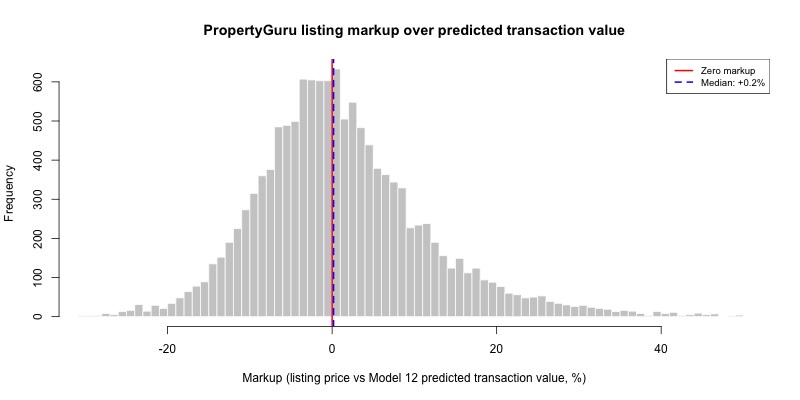

In [7]:
%%R -w 800 -h 400
# Markup distribution — trim to ±50% for readability
trim <- pg_complete$markup_pct[abs(pg_complete$markup_pct) < 50]

hist(trim,
     breaks = 100, col = 'grey80', border = 'white',
     main = 'PropertyGuru listing markup over predicted transaction value',
     xlab = 'Markup (listing price vs Model 12 predicted transaction value, %)',
     xlim = c(-30, 50))
abline(v = 0,                          col = 'red',  lwd = 2)
abline(v = median(pg_complete$markup_pct), col = 'blue', lwd = 2, lty = 2)
legend('topright',
    c('Zero markup',
      sprintf('Median: %+.1f%%', median(pg_complete$markup_pct))),
    col = c('red', 'blue'), lwd = 2, lty = c(1, 2), cex = 0.8)

In [8]:
%%R
# Markup by flat type
cat('Markup by flat type:\n')
cat(sprintf('%-20s %7s %10s\n', 'Flat type', 'N', 'Median markup'))
cat(paste(rep('-', 40), collapse = ''), '\n')
for (ft in sort(unique(pg_complete$flat_type))) {
    sub <- pg_complete[pg_complete$flat_type == ft, ]
    if (nrow(sub) >= 10) {
        cat(sprintf('%-20s %7s %+9.1f%%\n',
            ft, format(nrow(sub), big.mark = ','), median(sub$markup_pct)))
    }
}

cat('\nMarkup by price decile (predicted transaction value):\n')
pg_complete$decile <- cut(pg_complete$pred_txn,
    breaks = quantile(pg_complete$pred_txn, probs = seq(0, 1, 0.1)),
    labels = paste0('D', 1:10), include.lowest = TRUE)

cat(sprintf('%-10s %7s %10s %12s\n', 'Decile', 'N', 'Avg pred', 'Median markup'))
cat(paste(rep('-', 44), collapse = ''), '\n')
for (d in levels(pg_complete$decile)) {
    sub <- pg_complete[pg_complete$decile == d & !is.na(pg_complete$decile), ]
    if (nrow(sub) > 0) {
        cat(sprintf('%-10s %7s $%10s %+11.1f%%\n',
            d, format(nrow(sub), big.mark = ','),
            format(round(mean(sub$pred_txn)), big.mark = ','),
            median(sub$markup_pct)))
    }
}

Markup by flat type:


Flat type                  N Median markup


----------------------------------------

2 ROOM                   193      +9.9%


3 ROOM                 2,377      -1.7%


...

D6           1,300 $   699,591        -0.8%


D7           1,299 $   750,315        -0.7%


D8           1,303 $   818,800        +0.6%


D9           1,296 $   912,701        +1.9%


D10          1,300 $ 1,200,835        +7.0%


### Interpretation

Across 12,996 PropertyGuru HDB listings with complete data, the median asking price sits just +0.2% — about $1,089 — above what Model 12 predicts the flat would actually transact for. The mean is higher at +4.4% ($3,920), pulled up by a long right tail of aspirationally-priced listings. The market is broadly efficient in its listing behaviour: 51% of listings are above the predicted transaction value and 49% are below, meaning agents are not systematically anchoring high. The interquartile range runs from −5.5% to +7.0%, which is roughly the negotiation corridor the market has built in.

Listings with trailing 8s (3,617 in total) actually show a *smaller* average markup (+2.0%) than plain-priced listings (+5.4%). This is counter-intuitive but consistent with the transaction data from earlier notebooks: sellers who reach for auspicious endings tend to set prices that are already close to market value — the trailing 8 is a rounding device, not a stretch device. The 878 listings ending in 888 average +2.6% above predicted transaction value, again below the plain-priced baseline.

The eight 168-priced listings stand out with an average markup of +14.6% ($159,000 above predicted value), compared to +4.4% for everyone else. However, this is based on just eight listings and the t-test is not statistically significant (t = 1.22, p = 0.26), so no strong conclusions can be drawn. The five listings at the $1.168M price anchor show a more moderate +3.6% markup, which is actually below the plain-priced average — suggesting sellers targeting that specific round anchor are pricing closer to value, not further from it. The large 168 markup is driven by a handful of premium listings in expensive precincts where 168 appears as part of a high six-figure price string rather than as a deliberate psychological device.

The decile breakdown reveals where agent optimism concentrates: the top 10% of listings (predicted transaction value above ~$1.0M) carry a median markup of +7.0%, three to four times the markup in the middle of the market where deciles D2–D7 cluster between −1.6% and −0.8%. This pattern connects directly to the NB15 finding that 168-pricing is concentrated in the upper quartile of transactions — expensive flats are where both the psychological pricing and the listing stretch happen, and the two reinforce each other at the top end of the market.